# **TUGAS BESAR VISUALISASI DATA | KELOMPOK 09 | RB**

Meira Listyaningrum | 122450011

Priska Silvia Ferantiana | 122450053

Farahanum Afifah Ardiansyah | 122450056



## **Pre-Implementation**



### **Dataset**

1. Dataset POI List berisi informasi tentang titik-titik menarik (POI) yang dikunjungi pengguna Flickr. Terdapat beberapa variabel dalam dataset ini, yaitu: Variabel poiID adalah ID unik untuk setiap POI, sedangkan poiName memberikan nama POI. Koordinat geografis setiap POI tercatat dalam variabel lat (latitude) dan long (longitude). Variabel theme menggambarkan kategori POI, seperti "nature" atau "urban," yang membantu mengklasifikasikan jenis tempat yang dikunjungi.
2. Dataset User Visit mencatat aktivitas kunjungan pengguna ke POI. Beberapa variabel yang terdapat pada dataset ini yaitu: Variabel photoID adalah ID foto yang diambil saat kunjungan, dan userID mengidentifikasi pengguna. dateTaken mencatat tanggal kunjungan, sementara poiID menunjukkan POI yang dikunjungi. poiFreq menggambarkan frekuensi kunjungan, yang digunakan untuk menentukan popularitas POI, dan seqID menunjukkan urutan kunjungan pengguna ke POI.
3. Dataset CostProf mencatat biaya dan profit terkait perjalanan antar POI. Dataset ini memiliki beberapa variabel, yaitu: Variabel from dan to menunjukkan titik awal dan tujuan perjalanan, sedangkan cost dan profit mencatat biaya dan keuntungan masing-masing perjalanan. Variabel category memberikan informasi tambahan mengenai jenis perjalanan atau kategori POI. Dataset ini digunakan untuk menganalisis efisiensi biaya dan profitabilitas perjalanan antar POI.

### **Pertanyaan analisis visualisasi:**

1. Di mana lokasi POI yang paling populer dan paling banyak dikunjungi?
2. Kapan waktu puncak kunjungan di setiap POI?
3. Tema POI apa yang paling banyak dikunjungi oleh pengguna?
4. Tema POI apa yang paling menguntungkan berdasarkan rata-rata profit dan cost dari kunjungan?


### **Ide Cerita**

1. Menampilkan lokasi POI berdasarkan koordinat (latitude, longitude) dan menunjukkan kepadatan kunjungan di setiap POI.  Jadi users, dapat melihat area populer dan area yang jarang dikunjungi.
2. Menunjukkan perubahan jumlah kunjungan ke POI sepanjang waktu. Jadi users, dapat Mengidentifikasi tren musiman, waktu puncak, atau fluktuasi kunjungan. Hal ini bisa berguna untuk melihat waktu-waktu populer.
3. Mengelompokkan dan menampilkan distribusi kunjungan berdasarkan poiTheme (tema POI). Jadi users, dapat mengetahui preferensi umum pengguna berdasarkan tema POI yang paling banyak dikunjungi.
4. Menunjukkan profitabilitas atau biaya rata-rata dari kunjungan berdasarkan tema POI. Jadi users, dapat mengidentifikasi tema POI yang lebih menguntungkan atau yang membutuhkan biaya lebih rendah, berguna bagi pelaku bisnis yang ingin mengetahui area investasi terbaik.


## **Membaca data dan informasinya**

In [1]:
import pandas as pd
import numpy as np

In [35]:
# Membaca POI List
url1 = "https://raw.githubusercontent.com/meiralistya/Visualisasi-Data-dan-Informasi/bbb3b10c3f3506b3494535b878e907ec4a07c275/POI-Osak.csv"
poi_list = pd.read_csv(url1, sep=';')
print(poi_list.head())

# Membaca User Visit
url2 = "https://raw.githubusercontent.com/meiralistya/Visualisasi-Data-dan-Informasi/bbb3b10c3f3506b3494535b878e907ec4a07c275/userVisits-Osak.csv"
user_visit = pd.read_csv(url2, sep=';')
user_visit['dateTaken'] = pd.to_datetime(user_visit['dateTaken'], unit='s')
print(user_visit.head())

# Membaca CostProf
url3 = "https://raw.githubusercontent.com/meiralistya/Visualisasi-Data-dan-Informasi/bbb3b10c3f3506b3494535b878e907ec4a07c275/costProfCat-OsakPOI-all.csv"
cost_prof = pd.read_csv(url3, sep=';', quotechar='"')
print(cost_prof.head())

   poiID                  poiName        lat        long      theme
0      1  Osaka_Aquarium_Kaiyukan  34.654472  135.428889  Amusement
1      2    Tempozan_Ferris_Wheel  34.656166  135.431031  Amusement
2      3         Tenn%C5%8Dji_Zoo  34.652556  135.508496  Amusement
3      4  Universal_Studios_Japan  34.664720  135.433060  Amusement
4      5                 HEP_Five  34.704003  135.500447  Amusement
      photoID        userID           dateTaken  poiID       poiTheme  \
0  6656416589  10297518@N00 2010-06-28 10:02:04     20  Entertainment   
1  6656418463  10297518@N00 2010-06-28 10:02:24     20  Entertainment   
2  6656420371  10297518@N00 2010-06-28 10:05:41     20  Entertainment   
3  6656421479  10297518@N00 2010-06-28 10:05:58     20  Entertainment   
4  6656422763  10297518@N00 2010-06-28 10:06:13     20  Entertainment   

   poiFreq  seqID  
0      514      1  
1      514      1  
2      514      1  
3      514      1  
4      514      1  
   from  to         cost  profit 

## **Data Preprocessing**

### Data lokasi POI

In [3]:
# Gabungkan dataset POI List dengan User Visit berdasarkan POI ID
poi_visits = user_visit.groupby('poiID')['userID'].count().reset_index()
poi_visits.columns = ['poiID', 'poiFreq']

poi_density = pd.merge(poi_list, poi_visits, on='poiID', how='left')
poi_density['poiFreq'] = poi_density['poiFreq'].fillna(0)

# Output yang dihasilkan
poi_density[['poiID', 'lat', 'long', 'poiFreq']]


,poiID,lat,long,poiFreq
0,1,34.654472,135.428889,886.0
1,2,34.656166,135.431031,253.0
2,3,34.652556,135.508496,599.0
3,4,34.664720,135.433060,512.0
4,5,34.704003,135.500447,315.0
5,6,34.705280,135.489720,660.0
6,7,34.693056,135.506431,197.0
7,8,34.687220,135.525830,1307.0
8,9,34.612400,135.488480,5.0
9,10,34.649850,135.511110,412.0


### Perubahan Jumlah Kunjungan Sepanjang Waktu

In [4]:
# Agregasikan jumlah kunjungan per tahun
time_visits_year = user_visit.groupby(user_visit['dateTaken'].dt.to_period('Y'))['userID'].count().reset_index()
time_visits_year.columns = ['Year', 'poiFreq']

# Output yang dihasilkan
time_visits_year

,Year,poiFreq
0,1993,2
1,1998,2
2,2001,3
3,2002,8
4,2003,8
5,2004,21
6,2005,17
7,2006,231
8,2007,182
9,2008,626


In [5]:
# Agregasikan jumlah kunjungan per bulan
time_visits_month = user_visit.groupby(user_visit['dateTaken'].dt.to_period('M'))['userID'].count().reset_index()
time_visits_month.columns = ['Month', 'poiFreq']
time_visits_month

,Month,poiFreq
0,1993-07,2
1,1998-02,1
2,1998-12,1
3,2001-12,3
4,2002-10,8
...,...,...
111,2013-12,102
112,2014-01,40
113,2014-02,13
114,2014-03,94


In [56]:
# Tambahkan kolom nama bulan
user_visit['Month_Name'] = user_visit['dateTaken'].dt.strftime('%B')
user_visit['Month_Number'] = user_visit['dateTaken'].dt.month

# Agregasi kunjungan berdasarkan bulan
monthly_visits = user_visit.groupby(['Month_Number', 'Month_Name'])['userID'].count().reset_index()
monthly_visits.columns = ['Month_Number', 'Month_Name', 'Total_Visits']

# Urutkan bulan berdasarkan urutan kalender
monthly_visits = monthly_visits.sort_values(by='Month_Number')
monthly_visits

,Month_Number,Month_Name,Total_Visits
0,1,January,408
1,2,February,126
2,3,March,435
3,4,April,1869
4,5,May,528
5,6,June,287
6,7,July,640
7,8,August,497
8,9,September,497
9,10,October,1026


In [7]:
# Agregasikan jumlah kunjungan per hari
time_visits_day = user_visit.groupby(user_visit['dateTaken'].dt.to_period('D'))['userID'].count().reset_index()
time_visits_day.columns = ['Day', 'poiFreq']
time_visits_day

,Day,poiFreq
0,1993-07-31,2
1,1998-02-28,1
2,1998-12-31,1
3,2001-12-03,3
4,2002-10-18,8
...,...,...
848,2014-04-20,15
849,2014-04-21,2
850,2014-04-22,25
851,2014-04-26,45


In [59]:
# Tambahkan kolom nama hari
user_visit['Day_Name'] = user_visit['dateTaken'].dt.strftime('%A')
user_visit['Day_Number'] = user_visit['dateTaken'].dt.weekday

# Agregasi kunjungan berdasarkan hari
daily_visits = user_visit.groupby(['Day_Number', 'Day_Name'])['userID'].count().reset_index()
daily_visits.columns = ['Day_Number', 'Day_Name', 'Total_Visits']

# Urutkan hari berdasarkan urutan minggu
daily_visits = daily_visits.sort_values(by='Day_Number')
daily_visits

,Day_Number,Day_Name,Total_Visits
0,0,Monday,1324
1,1,Tuesday,1079
2,2,Wednesday,753
3,3,Thursday,1104
4,4,Friday,878
5,5,Saturday,1263
6,6,Sunday,1346


### Gabungkan dataset User Visit dengan POI List berdasarkan POI ID

In [9]:
# Gabungkan dataset
visit_theme = pd.merge(user_visit, poi_list[['poiID', 'theme']], on='poiID', how='left')

# Agregasikan kunjungan berdasarkan tema
theme_distribution = visit_theme.groupby('theme')['userID'].count().reset_index()
theme_distribution.columns = ['theme', 'poiFreq']

# Hitung distribusi persentase
theme_distribution['Percentage'] = (theme_distribution['poiFreq'] /
                                     theme_distribution['poiFreq'].sum()) * 100

# Output yang dihasilkan
theme_distribution


,theme,poiFreq,Percentage
0,Amusement,3225,41.629018
1,Entertainment,1915,24.719246
2,Historical,589,7.602943
3,Park,2018,26.048793


### Gabungkan dataset CostProf dengan POI List berdasarkan POI ID untuk mengetahui Profitabilitas atau Biaya Berdasarkan Tema POI

In [10]:
# Gabungkan `from` dengan POI List
cost_from = pd.merge(cost_prof, poi_list[['poiID', 'theme']], left_on='from', right_on='poiID', how='left')
cost_from.rename(columns={'theme': 'theme_from'}, inplace=True)

# Gabungkan `to` dengan POI List
cost_to = pd.merge(cost_from, poi_list[['poiID', 'theme']], left_on='to', right_on='poiID', how='left')
cost_to.rename(columns={'theme': 'theme_to'}, inplace=True)

# Drop kolom tambahan yang tidak diperlukan
cost_to.drop(columns=['poiID_x', 'poiID_y'], inplace=True)

# Output hasil
cost_to

,from,to,cost,profit,category,theme_from,theme_to
0,1,2,272.066373,253,Amusement,Amusement,Amusement
1,1,3,7292.894911,599,Amusement,Amusement,Amusement
2,1,4,1203.034337,512,Amusement,Amusement,Amusement
3,1,5,8562.257901,315,Amusement,Amusement,Amusement
4,1,6,7937.207231,660,Amusement,Amusement,Amusement
...,...,...,...,...,...,...,...
697,29,24,3165.418025,125,Entertainment,Entertainment,Entertainment
698,29,25,8645.031350,66,Entertainment,Entertainment,Entertainment
699,29,26,404620.589730,349,Entertainment,Entertainment,Entertainment
700,29,27,1499.829709,3,Entertainment,Entertainment,Entertainment


In [11]:
# Gabungkan tema asal dan tujuan menjadi satu kolom
cost_to['combined_theme'] = cost_to['theme_from'] + ' -> ' + cost_to['theme_to']

# Agregasikan rata-rata biaya dan profit berdasarkan kombinasi tema
profitability = cost_to.groupby('combined_theme')[['cost', 'profit']].mean().reset_index()
profitability.columns = ['Theme_Combination', 'Average_Cost', 'Average_Profit']

# Output hasil
profitability

,Theme_Combination,Average_Cost,Average_Profit
0,Amusement -> Amusement,5577.139343,537.500000
1,Amusement -> Entertainment,41759.501304,174.090909
2,Amusement -> Historical,6618.427258,147.250000
3,Amusement -> Park,6548.360385,336.333333
4,Entertainment -> Amusement,41759.501304,537.500000
5,Entertainment -> Entertainment,76083.610601,174.090909
6,Entertainment -> Historical,40576.585215,147.250000
7,Entertainment -> Park,40781.437785,336.333333
8,Historical -> Amusement,6618.427258,537.500000
9,Historical -> Entertainment,40576.585215,174.090909


In [12]:
# Berdasarkan tema asal
profitability_from = cost_to.groupby('theme_from')[['cost', 'profit']].mean().reset_index()
profitability_from.columns = ['Theme_From', 'Average_Cost', 'Average_Profit']

# Berdasarkan tema tujuan
profitability_to = cost_to.groupby('theme_to')[['cost', 'profit']].mean().reset_index()
profitability_to.columns = ['Theme_To', 'Average_Cost', 'Average_Profit']

# Output hasil
print(profitability_from)
print(profitability_to)


      Theme_From  Average_Cost  Average_Profit
0      Amusement  21269.387784      277.288462
1  Entertainment  54553.387746      291.265734
2     Historical  20394.023696      292.298077
3           Park  20556.499197      285.025641
        Theme_To  Average_Cost  Average_Profit
0      Amusement  21269.387784      537.500000
1  Entertainment  54553.387746      174.090909
2     Historical  20394.023696      147.250000
3           Park  20556.499197      336.333333


## **Visualisasi**

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### **1. Di mana lokasi POI yang paling populer dan paling banyak dikunjungi?**

Dari pertanyaan di atas akan dilihat bentuk visualisasi yang dapat menunjukkan lokasi POI  di Kota Osaka yang paling populer dan paling banyak dikunjungi oleh pengguna. Visualisasi ini berbentuk peta dengan titik-titik yang menunjukkan lokasi POI.

In [43]:
# Scatter map dengan nama lokasi/POI Name
fig = px.scatter_mapbox(
    poi_density,
    lat='lat',
    lon='long',
    size='poiFreq',
    color='poiFreq',
    hover_name='poiName',
    hover_data={'lat': False, 'long': False, 'poiFreq': True},
    title='Lokasi POI dan Kepadatan Kunjungan di Osaka, Jepang',
    mapbox_style='carto-positron',
    zoom=12,
    center={'lat': 34.6937, 'lon': 135.5023}  # Fokus ke Osaka
)

fig.update_layout(
    mapbox=dict(
        bearing=0,
        pitch=0,
    )
)

fig.show()

Dari visualisasi yang ditampilkan, terdapat gradasi warna pada baris legenda (sebelah kanan) yang mana warna berubah dari ungu ke kuning, dimana ungu merupakan frekuensi rendah dan kuning merupakan frekuensi tinggi. Selanjutnya adanya ukuran titik, dimana titik yang lebih besar menunjukkan POI dengan frekuensi kunjungan yang lebih tinggi dan titik kecil mewakili POI dengan kunjungan yang lebih sedikit. Poi yang paling banyak dikunjungi di Osaka tampak sebagai titik besar dengan warna kuning, yaitu di Osaka castle, dan beberapa titik lain dengan warna merah muda atau ungu menunjukkan POI dengan kunjungan yang sedang. POI kuning besar memiliki frekuensi kunjungan lebih dari 1200 dan POI dengan warna lain memiliki frekuensi kunjungan yang jauh lebih rendah. Dapat disimpulkan, POI dengan titik kuning besar yaitu Osaka castle adalah POI dengan frekuensi kunjungan tertinggi (sekitar 1200).

### **2. Kapan waktu puncak kunjungan di setiap POI?**

Pertanyaan di atas akan menunjukkan waktu puncak kunjungan di setiap POI berdasarkan jumlah kunjungan oleh pengunjung dari tahun 1993 hingga tahun 2014, kemudian terdapat pula waktu puncak kunjungan berdasarkan jumlah kunjungan dalam satu tahun dan dalam satu minggu.

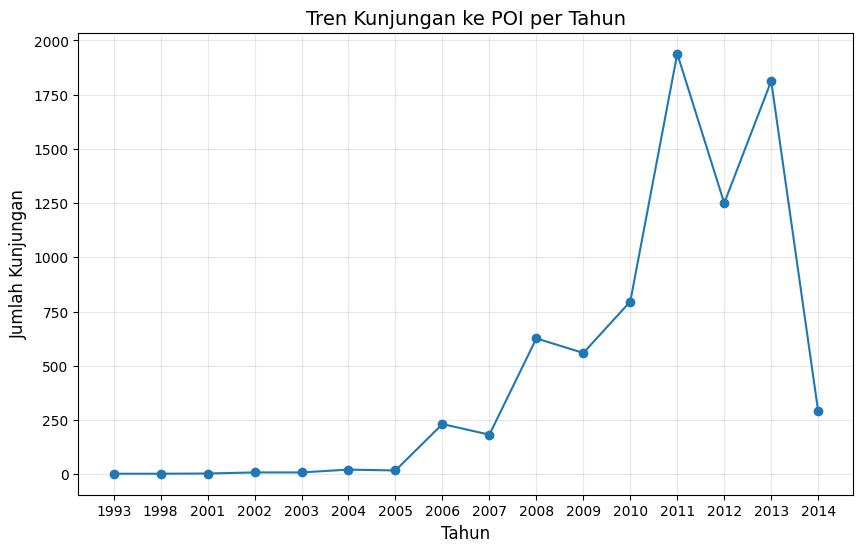

In [15]:
# Pertahun
plt.figure(figsize=(10, 6))
plt.plot(time_visits_year['Year'].astype(str), time_visits_year['poiFreq'], marker='o')
plt.title('Tren Kunjungan ke POI per Tahun', fontsize=14)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Kunjungan', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

Dari visualisasi yang dihasilkan, dapat dilihat bahwa waktu puncak kunjungan terjadi pada tahun 2011 dan 2012 yang menunjukkan jumlah kunjungan tertinggi dengan sekitar 2000 kunjungan pada grafik, dan periode tersebut dapat diindikasikan sebagai puncak kunjungan ke POI. Terdapat juga periode kenaikan yang signifikan dimulai pada tahun 2005 hingga 2010, dimana jumlah kunjungan terus bertambah secara bertahap dari tahun ke tahun. Terjadi juga periode penurunan yaitu setelah puncak tahun 2012, dimana terjadi penurunan signifikan pada tahun 2014, yang mana kunjungan turun hingga di bawah 500 kunjungan. Dapat disimpulkan, bahwa waktu puncak kunjungan di setiap POI adalah pada tahun 2011 dan 2012, dengan jumlah kunjungan sekitar 2000 kunjungan.

<ipython-input-57-a6b44bf12b75>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




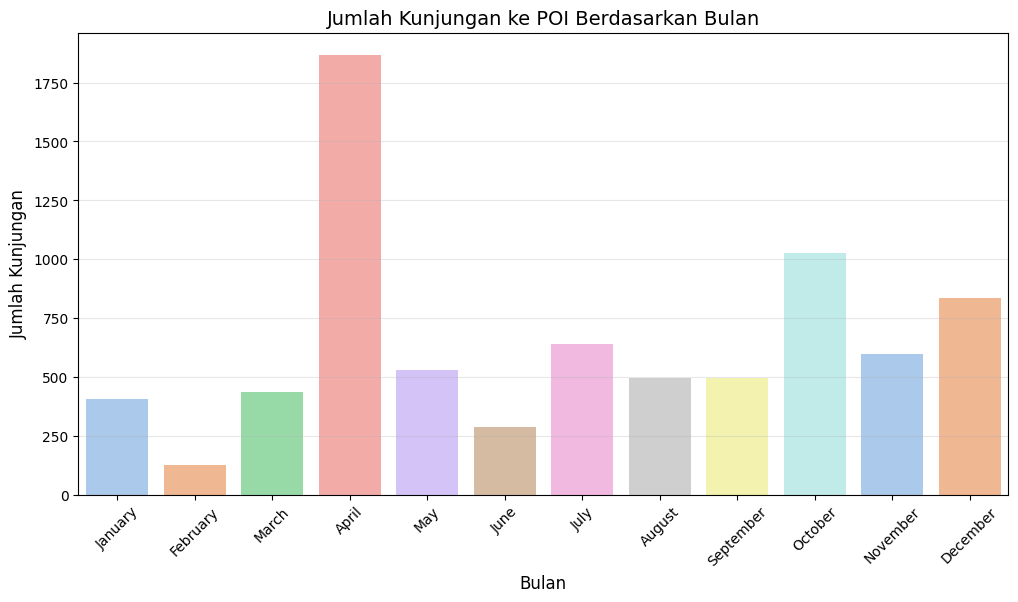

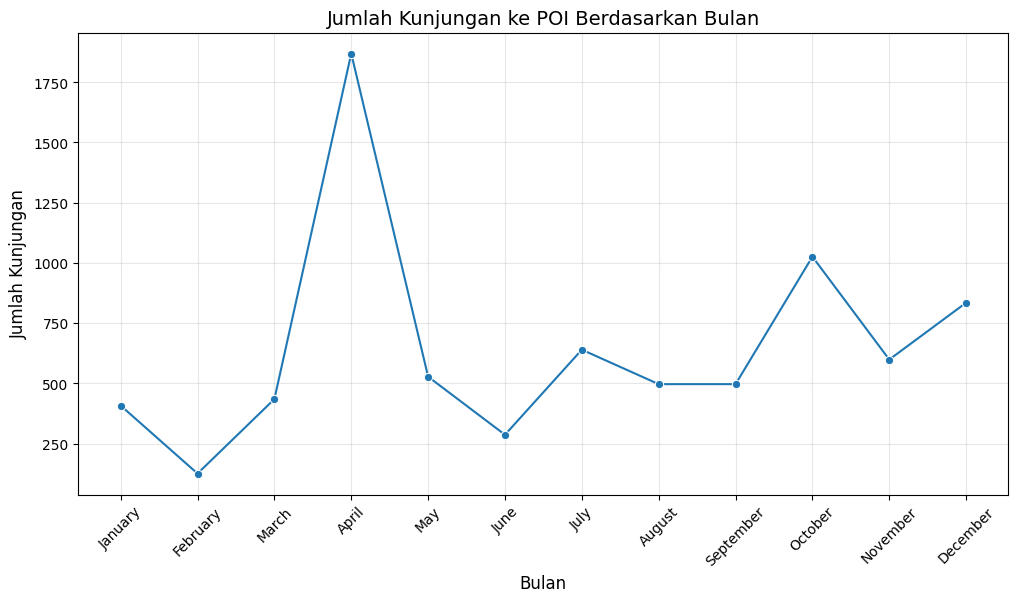

In [57]:
# Per bulan
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_visits, x='Month_Name', y='Total_Visits', palette='pastel')
plt.title('Jumlah Kunjungan ke POI Berdasarkan Bulan', fontsize=14)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Kunjungan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Line chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_visits, x='Month_Name', y='Total_Visits', marker='o', sort=False)
plt.title('Jumlah Kunjungan ke POI Berdasarkan Bulan', fontsize=14)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Kunjungan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

Dari visualisasi yang ditampilkan, puncak kunjungan terdapat pada April, dengan jumlah kunjungan hampir 1750. Kunjungan paling rendah terjadi pada bulan Februari dengan kunjungan di bawah 250 kunjungan. Dapat disimpulkan bahwa waktu puncak kunjungan ke POI di Osaka adalah pada bulan April, yang hal ini kemungkinan terjadi karena popularitas musim semi dan aktivitas terkait seperti melihat bunga sakura, yang mana pola musiman yang terjadi menunjukkan bahwa kunjungan ke POI sangat dipengaruhi oleh faktor - faktor seperti budaya, musim, serta pariwisata.


<ipython-input-58-4e8f2056e886>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




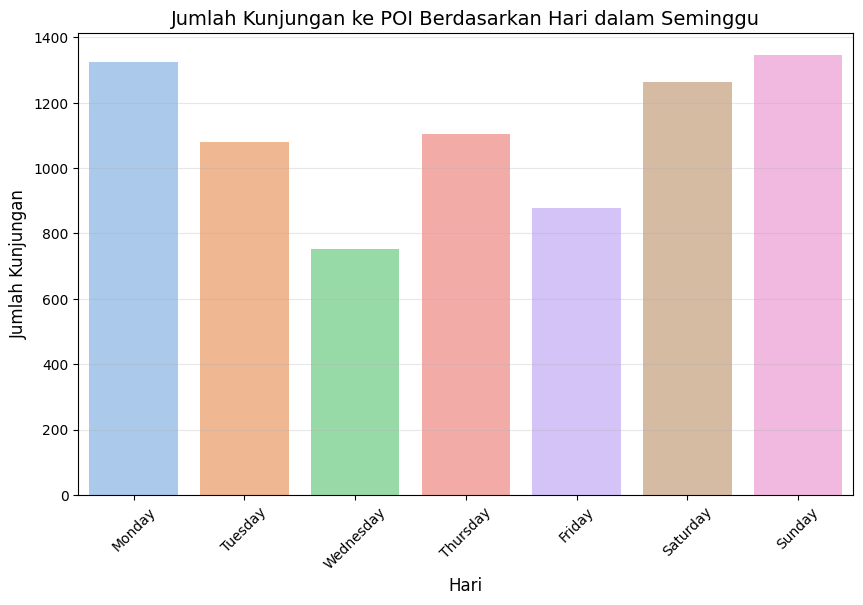

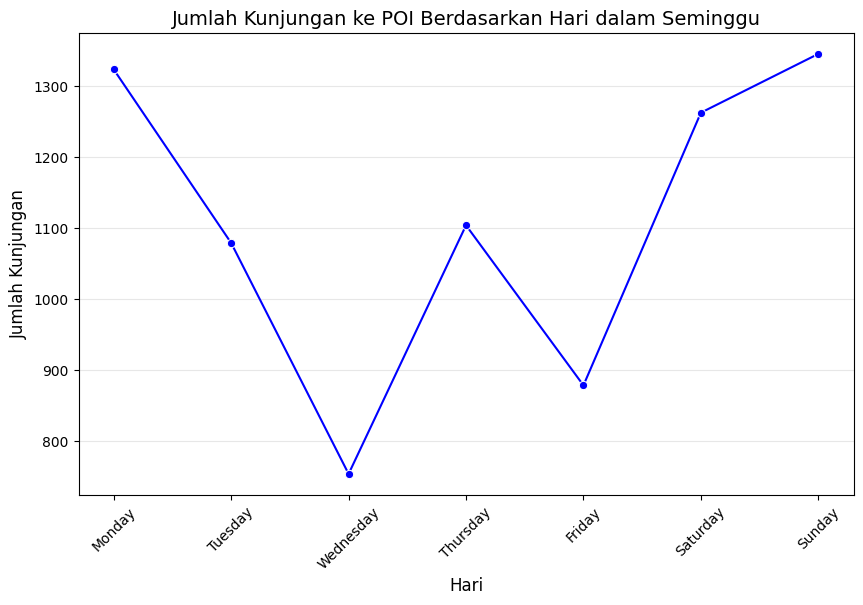

In [58]:
# Per hari
plt.figure(figsize=(10, 6))
sns.barplot(data=daily_visits, x='Day_Name', y='Total_Visits', palette='pastel')
plt.title('Jumlah Kunjungan ke POI Berdasarkan Hari dalam Seminggu', fontsize=14)
plt.xlabel('Hari', fontsize=12)
plt.ylabel('Jumlah Kunjungan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Line chart
plt.figure(figsize=(10, 6))
sns.lineplot(data=daily_visits, x='Day_Name', y='Total_Visits', marker='o', color='b')
plt.title('Jumlah Kunjungan ke POI Berdasarkan Hari dalam Seminggu', fontsize=14)
plt.xlabel('Hari', fontsize=12)
plt.ylabel('Jumlah Kunjungan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

Dari visualisasi yang ditampilkan, dapat dilihat hari dengan jumlah kunjungan tertinggi adalah pada hari sunday (minggu) dengan jumlah kunjungan sekitar 1300 kunjungan. Hal ini menunjukkan bahwa hari minggu merupakan puncak tertinggi kunjungan ke POI yang kemungkinan besar hal ini terjadi karena hari tersebut merupakan hari libur yang mendorong masyarakat untuk bepergian atau berwisata. Terdapat juga tren jumlah kunjungan yang terjadi pada hari senin yang mana jumlah kunjungannya cukup tinggi namun menurun drastis pada hari selasa. Pola mingguan yang terjadi menunjukkan bahwa kunjungan ke POI cenderung rendah pada tengah minggu (selasa hingga kamis), yang kemungkinan terjadi karena hari kerja. Sebaliknya, pada akhir pekan (sabtu dan minggu) menunjukkan kunjungan ke POI yang tinggi karena banyak orang yang memanfaatkan waktu luang atau liburnya untuk rekreasi.

### **3. Tema POI apa yang paling banyak dikunjungi oleh pengguna?**

Pertanyaan ketiga akan menunjukkan tema Point of Interest Kota Osaka yang paling banyak dikunjungi oleh pengguna berdasarkan jumlah kunjungan. Visualisasi ini akan menunjukkan besaran distribusi kunjungan dari keempat tema POI tersebut.


<ipython-input-52-3f09fb900dba>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




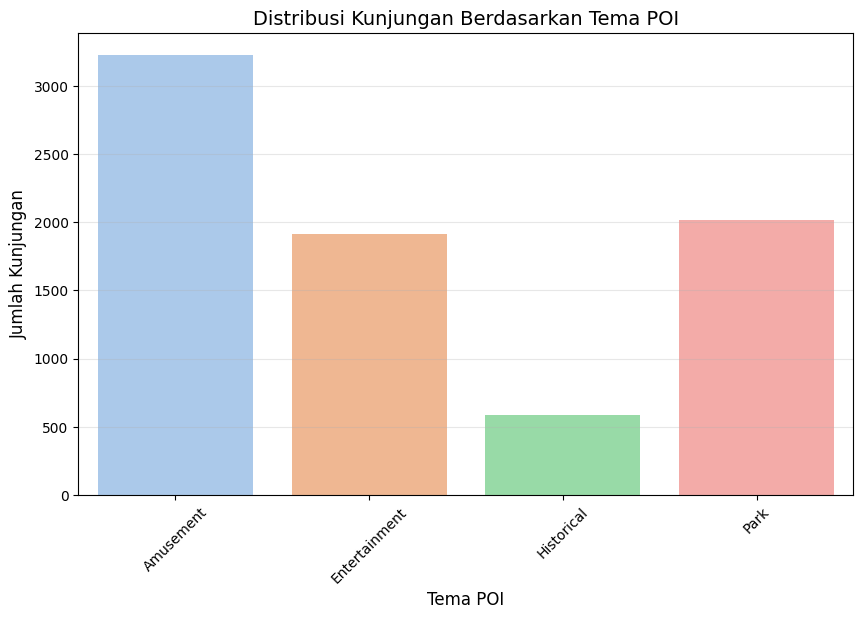

In [52]:
# Barchart
plt.figure(figsize=(10, 6))
sns.barplot(data=theme_distribution, x='theme', y='poiFreq', palette='pastel')
plt.title('Distribusi Kunjungan Berdasarkan Tema POI', fontsize=14)
plt.xlabel('Tema POI', fontsize=12)
plt.ylabel('Jumlah Kunjungan', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

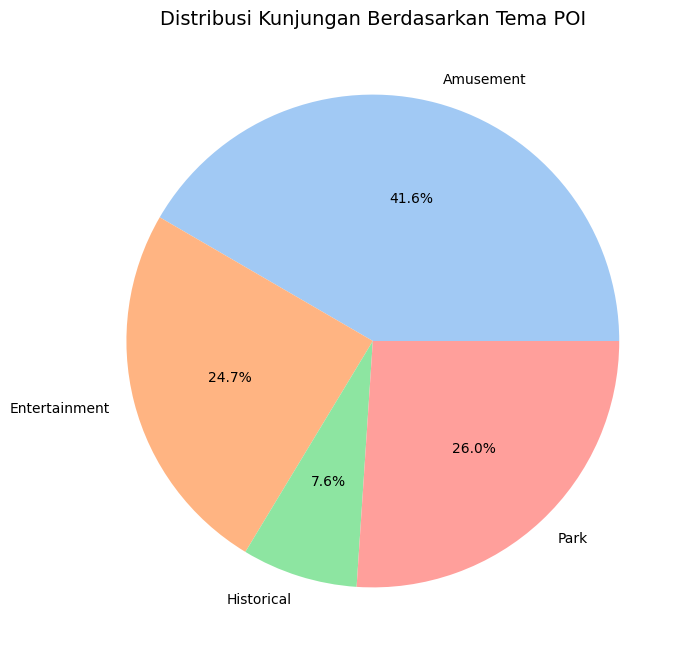

In [51]:
# Pie Chart
plt.figure(figsize=(8, 8))
plt.pie(theme_distribution['poiFreq'], labels=theme_distribution['theme'], autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Distribusi Kunjungan Berdasarkan Tema POI', fontsize=14)
plt.show()

Dari visualisasi diagram lingkaran tersebut dapat dilihat bahwa setiap tema Point of Interest memiliki persentase jumlah kunjungan. Tema Amusement memiliki persentase tertinggi sebesar 41.6%, hal ini menunjukkan bahwa tempat dengan tema Amusement paling banyak dikunjungi dan diminati oleh pengguna. Selanjutnya tema Park dengan persentase jumlah kunjungan sebesar 26%. Kemudian tema Entertainment sebesar 24.7% dan tema Historical sebesar 7.6%.


### 4. **Tema POI apa yang paling menguntungkan berdasarkan rata-rata profit dan cost dari kunjungan?**

Pertanyaan di atas akan menunjukkan tema POI yang paling menguntungkan dilihat dari rata-rata nilai profit dan cost dari semua kunjungan. Dari visualisasinya kita dapat mengidentifikasi tema POI yang lebih menguntungkan atau yang membutuhkan biaya lebih rendah. Visualisasi ini berbentuk bar chart untuk memudahkan melihat perbandingan rata-rata profit dan cost setiap tema.


<ipython-input-49-a311a8d3361f>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




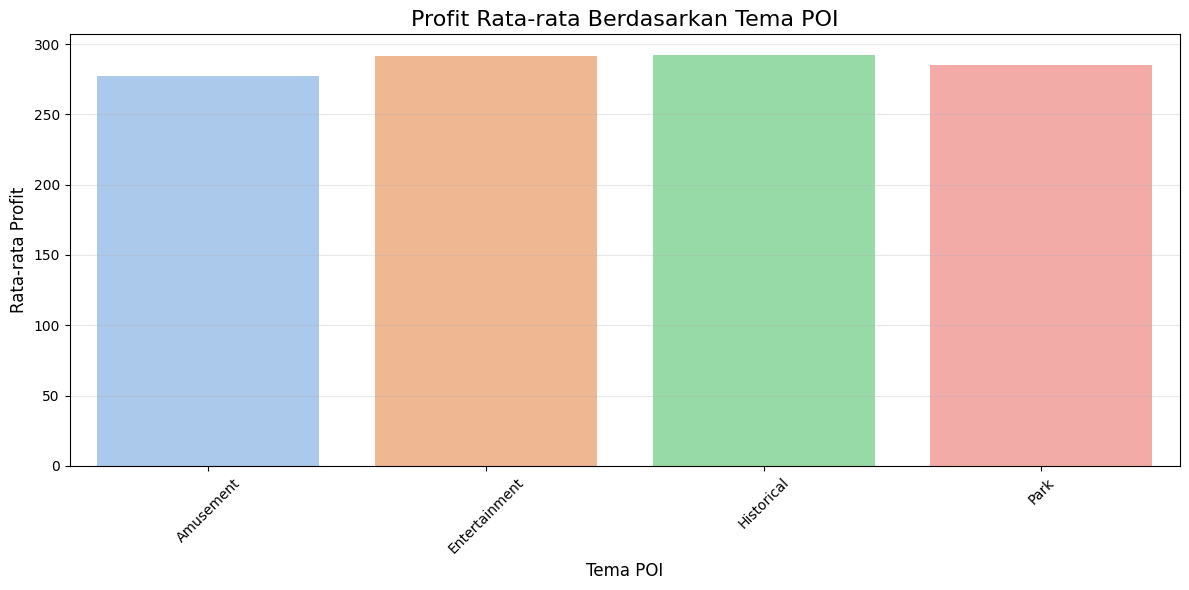

In [49]:
# Plot bar chart untuk Average_Profit
plt.figure(figsize=(12, 6))
sns.barplot(data=profitability_from, x='Theme', y='Average_Profit', palette='pastel')

# Menambahkan label
plt.title('Profit Rata-rata Berdasarkan Tema POI', fontsize=16)
plt.xlabel('Tema POI', fontsize=12)
plt.ylabel('Rata-rata Profit', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Tampilkan plot
plt.tight_layout()
plt.show()


Dari visualisasi di atas, kita dapat mengetahui bahwa profit rata-rata dari setiap tema tidak jauh berbeda atau memiliki tingkat profit yang relatif sama. Namun, dapat kita lihat bahwa profit atau keuntungan terbesar adalah POI dengan tema historical dan entertaiment. Tema POI amusement memiliki tingkat profit terendah dari semua tema, meskipun perbandingannya tidak jauh berbeda. Informasi ini cukup berguna bagi pelaku bisnis untuk mengetahui bahwa investasi di berbagai tema POI memiliki profit yang hampir seimbang.

<ipython-input-55-7e8ac5b21781>:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




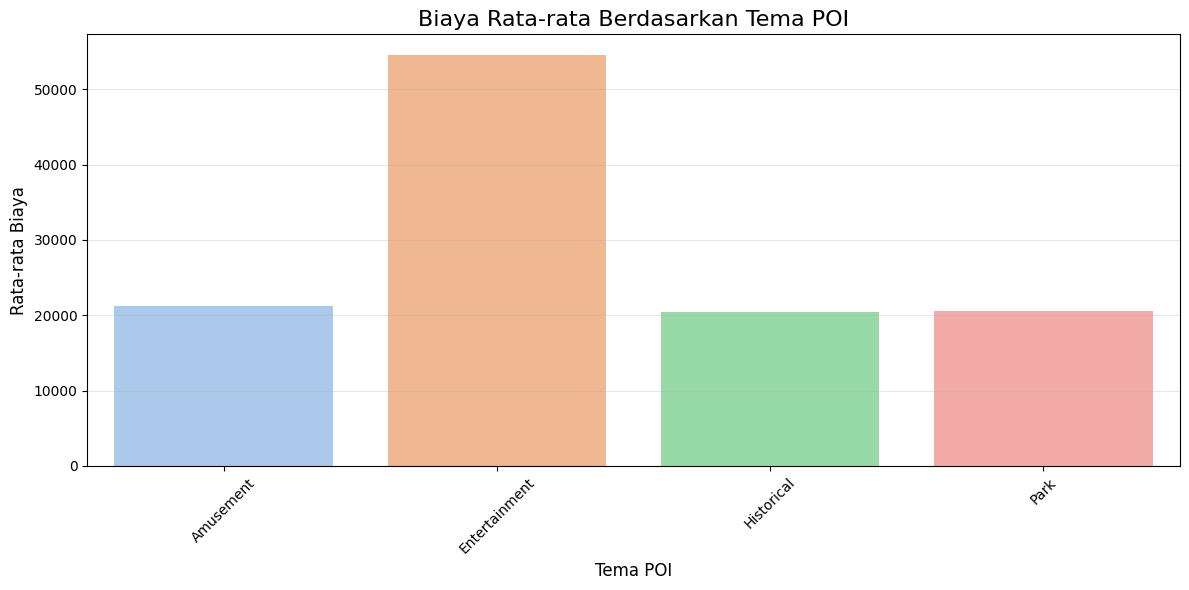

In [55]:
# Plot bar chart untuk Average_Cost
plt.figure(figsize=(12, 6))
sns.barplot(data=profitability_from, x='Theme', y='Average_Cost', palette='pastel')

# Menambahkan label
plt.title('Biaya Rata-rata Berdasarkan Tema POI', fontsize=16)
plt.xlabel('Tema POI', fontsize=12)
plt.ylabel('Rata-rata Biaya', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Tampilkan plot
plt.tight_layout()
plt.show()

## **Kesimpulan**

Berdasarkan visualisasi dan analisis dari kunjungan POI di Osaka dapat disimpulkan bahwa:

1. Berdasarkan lokasinya, POI yang paling populer dan banyak dikunjungi di Osaka adalah Osaka Castle yang memiliki jumlah frekuensi pengunjung sebanyak lebih dari 1200 pengunjung.
2. Berdasarkan waktu, visualisasi menunjukkan bahwa puncak kunjungan POI terjadi pada tahun 2011 dan 2012. Sementara jika dalam bulan puncak kunjungan POI di Osaka terjadi pada bulan april. Puncak kunjungan terjadi pada hari minggu ketika dibuat dalam bentuk minggu.
3. Berdasarkan preferensi pengguna, tema POI yang paling banyak dikunjungi di Osaka adalah POI dengan tema Amusement dengan persentase sebesar 41.6%.
4. Berdasarkan profit, keempat tema POI tersebut memiliki profit yang relatif sama dan tidak ada perbedaan yang signifikan dengan tema yang memiliki profit terbesar yaitu POI dengan tema Historical dan Entertainment. Sedangkan berdasarkan cost atau biaya, POI dengan tema Amusement, Historical, dan Park memiliki cost yang relatif rendah jika dibandingkan dengan Entertainment yang jauh lebih tinggi.

Dari keempat poin di atas kita dapat mengetahui bahwa visualisasi memuat informasi yang dapat membantu kita mengenal pola kunjungan POI di Osaka berdasarkan lokasi, waktu dan preferensi pengguna. Selain itu kita juga dapat mengetahui tema POI di Osaka yang memiliki keuntungan paling besar serta biaya paling kecil.
